# Clustering time series
This notebook is going to be an organized way of cluster time series using an algorithm which can take multivariate data. The data will be structure in the following way: each phosphorylation site will be an entrance to the dataset, it will have 3 different variables which correspond to the different experiment conditions (EGF, INS, EGFnINS). 

 https://github.com/Kenan-Li/dtwsom 

In [1]:
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
# %matplotlib inline
import numpy as np
import os
import sys
import inspect

import dtwsom
import pickle
from sklearn.cluster import KMeans

from tslearn_clustering import data_type

Steps:
- Load dataframe
- Reformating the dataframe to fit the multivariate project

In [2]:
df = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_functional_names_diff_scaled.xlsx")
#"Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_FC_nrep_SD_log2FC1_nRep2_allPhosphoFound_True.xlsx")
df = df.fillna(0)

In [4]:
column_names = df.columns.tolist()

data_type = "log2_FC"

time_series_conditions = [element for element in column_names if f"{data_type}_" in element]
EGF = [element for element in column_names if f"{data_type}_EGF_" in element]
INS = [element for element in column_names if f"{data_type}_INS_" in element]
EGFnINS = [element for element in column_names if f"{data_type}_EGFnINS_" in element]

x_axis_previous = [element for element in column_names if f"log2_FC_EGF_" in element]  # this could be any set of columns that have the time points
time_points = [s.split("_")[-1] for s in x_axis_previous]


In [6]:
def reshape_df(df, time_series, dimensions, len_time_serie):
    '''Reshape dataframe so it is multivariate. Return the dataframe in numpy format so can be used, and list with the names of myseries'''
    
    sub_df = df[time_series].copy()
    mySeries = sub_df.to_numpy()
    namesofMySeries = df["site"]
    
    multivariate_shape = (len(df), dimensions, len_time_serie)
    multivariate_df = np.reshape(mySeries, multivariate_shape)
    
    return multivariate_df, namesofMySeries
    

In [7]:
multivariate_df, names_of_myseries = reshape_df(df = df, time_series = time_series_conditions, dimensions = 3, len_time_serie = 7)

In [8]:
som = dtwsom.MultiDtwSom(x=9, y=9, input_len=multivariate_df.shape[2], bands=multivariate_df.shape[1], w=[1/3, 1/3, 1/3], sigma=1, learning_rate=0.5, random_seed=10, gl_const="sakoe_chiba", scr= 2)
som.pca_weights_init(multivariate_df)
som.train_batch(multivariate_df, 5000, verbose=True)
weights = som.get_weights()

 [ 5000 / 5000 ] 100% - 24.87 it/s - 0:00:00 left  - quantization error: 0.2664476159191508


In [37]:
## Save the model so that you do not need to train it again
# with open('Experiment/1_hTERT_HME1/Results/Clusters/Cluster2/Multivariate_log2FC0_nRep1_allPhosphoFound_True.pkl', 'wb') as f:
#    pickle.dump(som, f)

In [10]:
KMeans_X = np.stack((np.array(weights)[0]+np.array(weights)[1]+np.array(weights)[2]).reshape(81, 7))
KMeans_all = KMeans(n_clusters=8, random_state=0).fit(KMeans_X)
KMeans_all.labels_

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([6, 6, 6, 6, 1, 1, 5, 5, 3, 6, 6, 6, 6, 1, 1, 5, 5, 3, 6, 6, 6, 6,
       1, 1, 1, 5, 5, 6, 7, 7, 6, 6, 1, 1, 1, 1, 2, 2, 2, 7, 7, 7, 7, 1,
       1, 2, 2, 2, 2, 7, 7, 7, 7, 7, 2, 2, 2, 2, 7, 7, 7, 7, 7, 0, 0, 2,
       2, 2, 7, 7, 7, 7, 4, 0, 2, 2, 2, 7, 7, 7, 7], dtype=int32)

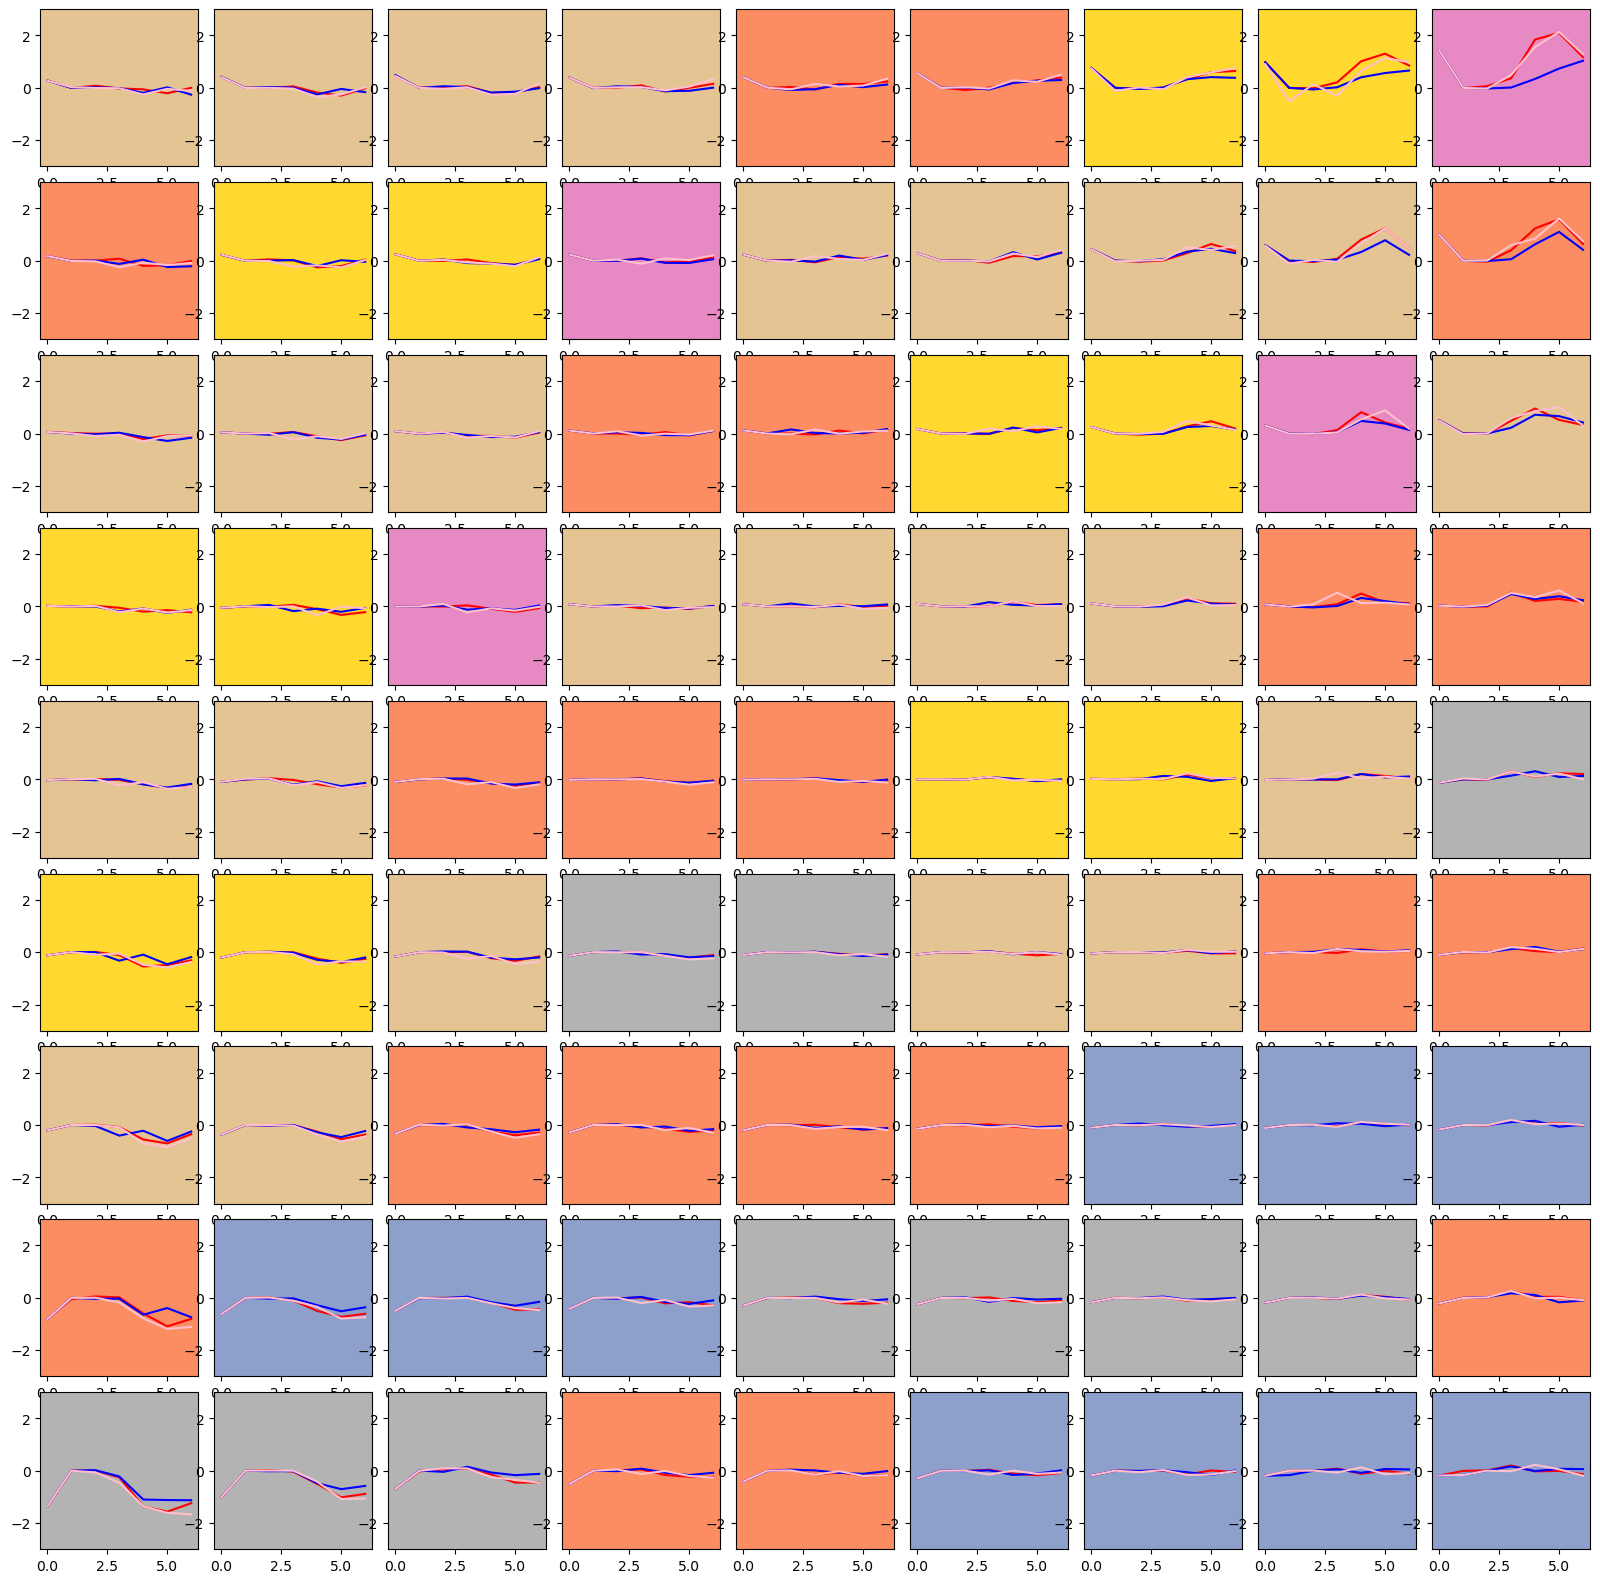

In [11]:
plt.figure(figsize=(20, 20))
norm = matplotlib.colors.Normalize(vmin=0, vmax=7, clip=True)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.Set2)
for i in range(9):
    maxylim= np.max(names_of_myseries)
    for j in range(9):
        ax = plt.subplot(9, 9, i*9 + 1+j)
        ax.get_xaxis().set_visible(True)
        ax.get_yaxis().set_visible(True)
        ax.set_ylim((-3,3))
        plt.plot(np.array(weights)[0, i, j, :], color= 'red')
        plt.plot(np.array(weights)[1, i, j, :], color= 'blue')
        plt.plot(np.array(weights)[2, i, j, :], color= 'pink')

        ax.set_facecolor(mapper.to_rgba(KMeans_all.labels_[i*5 +j]))
plt.subplots_adjust(wspace=0.1, hspace=0.1)
# plt.savefig('Experiment/1_hTERT_HME1/Results/Clusters/Cluster2/Plotting_with_weights.pdf')

In [12]:
all_winners_by_site_df = pd.DataFrame(index = names_of_myseries, columns = range(8), data = 0)
for s in all_winners_by_site_df.index:
    data = df[df.site==s]
    data_s = np.swapaxes(np.array([np.stack(multivariate_df[0]), np.stack(multivariate_df[1]), np.stack(multivariate_df[2])]), 0, 1)
    for i in data_s:
        x = som.winner(i)[0]
        y = som.winner(i)[1]
        all_winners_by_site_df.loc[s,KMeans_all.labels_[x*10 +y]] += 1
all_winners_by_site_df

,0,1,2,3,4,5,6,7
site,,,,,,,,
A0A2R8Y4L2_152_154_1_0~SGSGNFGGGR,0,0,0,0,0,2,1,0
A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,0,0,0,0,0,2,1,0
A0A2R8Y4L2_260_271_1_0~NQGGYGGSSSSSSYGSGR,0,0,0,0,0,2,1,0
A0A2R8Y4L2_260_271_1_1_S264~NQGGYGGSsSSSSYGSGR,0,0,0,0,0,2,1,0
A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,0,0,0,0,0,2,1,0
...,...,...,...,...,...,...,...,...
Q9Y6Y0_336_338_1_1_S338~SLsFEMQQDELIEK,0,0,0,0,0,2,1,0
Q9Y6Y0_336_356_1_0~SLSFEMQQDELIEKPMSPMQYAR,0,0,0,0,0,2,1,0
Q9Y6Y0_336_356_1_1_S338~SLsFEMQQDELIEKPMSPMQYAR,0,0,0,0,0,2,1,0


In [13]:
winners_in_map = som.labels_map(multivariate_df, names_of_myseries)
winners_in_map #??????

KeyboardInterrupt: 

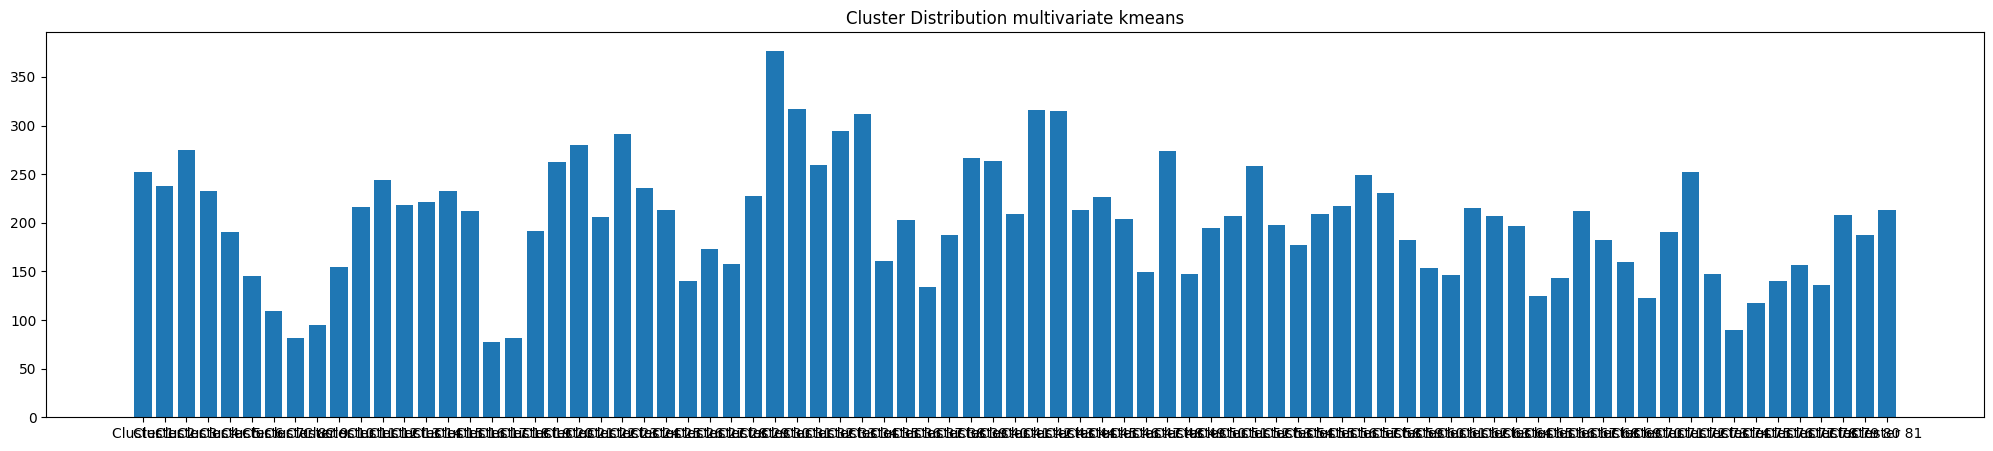

In [42]:
win_map = som.win_map(multivariate_df)
cluster_c = []
cluster_n = []
for x in range(9):
    for y in range(9):
        cluster = (x,y)
        if cluster in win_map.keys():
            cluster_c.append(len(win_map[cluster]))
        else:
            cluster_c.append(0)
        cluster_number = x*9+y+1
        cluster_n.append(f"Cluster {cluster_number}")

plt.figure(figsize=(25,5))
plt.title("Cluster Distribution multivariate kmeans")
plt.bar(cluster_n,cluster_c)
# plt.savefig(f"Experiment/1_hTERT_HME1/Results/Clusters/Cluster2/Kmean_weights_distribution.pdf")
plt.show()

In [14]:
cluster_map = []
for idx in range(len(multivariate_df)):
    winner_node = som.winner(multivariate_df[idx])
    cluster_map.append((names_of_myseries[idx],f"{winner_node[0]*9+winner_node[1]+1}"))
                        #multivariate_df[idx]
save_cluster = pd.DataFrame(cluster_map,columns=["site","dtwsom_clusters"]) #.sort_values(by="dtwsom_clusters")
# save_cluster.to_excel("Experiment/1_hTERT_HME1/Results/Clusters/Cluster2/Clusters.xlsx", index=False)
save_cluster

,site,dtwsom_clusters
0,A0A2R8Y4L2_152_154_1_0~SGSGNFGGGR,7
1,A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,9
2,A0A2R8Y4L2_260_271_1_0~NQGGYGGSSSSSSYGSGR,66
3,A0A2R8Y4L2_260_271_1_1_S264~NQGGYGGSsSSSSYGSGR,72
4,A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,65
...,...,...
34997,Q9Y6Y0_336_338_1_1_S338~SLsFEMQQDELIEK,43
34998,Q9Y6Y0_336_356_1_0~SLSFEMQQDELIEKPMSPMQYAR,69
34999,Q9Y6Y0_336_356_1_1_S338~SLsFEMQQDELIEKPMSPMQYAR,33
35000,Q9Y6Y8_118_138_1_0~PLTALPFTTGSQDVSNAFSPSISK,62


In [44]:
clustered_df = df.copy()
clustered_df['Clusters'] = False
for row in clustered_df.itertuples():
    index = row[0]
    site = row[3]
    # print(row[48])
    clustered_df.at[index,"Clusters"] = save_cluster.loc[index]['Cluster']
clustered_df.to_excel("Experiment/1_hTERT_HME1/Results/Clusters/Cluster2/Handmade_Log2_FC_from_FGZC_log2FC0_nRep1_allPhosphoFound_True_Clusters.xlsx", index=False)
clustered_df


,protein_ID,prot_name,site,EGF_full,EGF_starve,EGF1,EGF2,EGF5,EGF10,EGF90,...,INS10_std,INS90_std,EGFnINS_full_std,EGFnINS_starve_std,EGFnINS1_std,EGFnINS2_std,EGFnINS5_std,EGFnINS10_std,EGFnINS90_std,Clusters
0,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,2.750617,0,-0.075632,0.051413,0.553841,1.071310,0.614675,...,0.082451,0.158647,0.240242,0.073607,0.213038,0.017743,0.137722,0.158750,0.203929,Cluster 81
1,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_1_S264~NQGGYGGSsSSSSYGSGR,-0.337808,0,0.099901,0.026794,-0.030970,-0.071683,-0.061284,...,0.228683,0.101860,0.015341,0.096143,0.177090,0.027352,0.391594,0.279341,0.065133,Cluster 14
2,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,-0.726273,0,-0.103509,-0.389250,-0.566986,-0.520466,-0.750087,...,0.092438,0.135065,0.190606,0.107901,0.087274,0.362086,0.085434,0.223696,0.084909,Cluster 2
3,A0A3B3IU46,RAMACL,A0A3B3IU46_36_45_1_1_S36~RPPEsPPIVEEWNSR,0.110552,0,-0.017930,0.050637,0.032732,0.071821,0.131738,...,0.210750,0.300944,0.029332,0.103261,0.168419,0.102455,0.158562,0.151840,0.085736,Cluster 59
4,A0AVK6,E2F8,A0AVK6_52_60_1_1_T58~EGSQGEPWtPTANLK,0.135288,0,-0.078561,-0.017174,0.135621,0.130103,0.278156,...,0.178745,0.136126,0.157350,0.180260,0.171977,0.151420,0.140398,0.226174,0.212396,Cluster 52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16299,Q9Y6X9,MORC2,Q9Y6X9_773_785_1_1_S779~KDSNELSDsAGEEDSADLKR,-0.151203,0,-0.165513,-0.151805,-0.200414,-0.135701,0.025294,...,0.188875,0.066557,0.001353,0.134660,0.000697,0.012122,0.074536,0.028049,0.061797,Cluster 16
16300,Q9Y6Y0,IVNS1ABP,Q9Y6Y0_246_246_1_1_S246~LLDGNLLDGQAEVFGsDDDHIQ...,-0.192902,0,0.062341,0.079200,-0.004977,0.077238,-0.016268,...,0.095150,0.121282,0.069927,0.109015,0.018727,0.106886,0.087003,0.105712,0.108007,Cluster 26
16301,Q9Y6Y0,IVNS1ABP,Q9Y6Y0_336_338_1_1_S338~SLsFEMQQDELIEK,0.030638,0,0.107473,-0.008990,0.060896,0.015639,0.004748,...,0.118530,0.209883,0.140928,0.190284,0.162495,0.153906,0.077442,0.173945,0.194352,Cluster 43
16302,Q9Y6Y0,IVNS1ABP,Q9Y6Y0_336_356_1_1_S338~SLsFEMQQDELIEKPMSPMQYAR,0.089820,0,0.002724,0.082102,0.025246,0.015418,0.111233,...,0.092533,0.092859,0.181606,0.183772,0.186855,0.092704,0.159401,0.079835,0.147529,Cluster 43


In [45]:
# clustered_df.to_excel(f"clustered_df_FC1_25.xlsx", index=False)